# Single cell analysis CCR9 gene

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import scanpy as sc
import anndata as ad
import pandas as pd
import os
import math
import tarfile
import gzip


In [2]:
#setting verbosity and figure params
sc.settings.verbosity = 0 # show only error message
sc.settings.set_figure_params(
    dpi = 80,
facecolor = "white",
frameon = True,
)

In [3]:
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
print(sc.__version__)

1.9.6


In [444]:
# N.B. PROCESSED DATA

In [445]:
#tar_file_path = 'GSE123139_RAW.tar'

# Initialize an empty list to hold DataFrames
#dataframes = []

# Open the tar file
#with tarfile.open(tar_file_path, 'r') as tar:
    # List all members in the tar file
    #for member in tar.getmembers():
        # Check if the member is a file with the .txt.gz extension
       # if member.isfile() and member.name.endswith('.txt.gz'):
            # Extract the file
            #f = tar.extractfile(member)
            # Use gzip to read the compressed file
            #with gzip.open(f, 'rt') as gz:
                # Read the extracted file into a pandas DataFrame
                #df = pd.read_csv(gz, sep='\t')  # Adjust the separator as needed
                # Append the DataFrame to the list
                #dataframes.append(df)


In [446]:
# Concatenate all DataFrames in the list into one big DataFrame
#combined_df = pd.concat(dataframes, axis = 1, join = 'inner')

In [447]:
#CCR9 = combined_df.T[['CCR9']]

In [448]:
#df = combined_df.T

In [449]:
# Create AnnData object
#adata = ad.AnnData(X=df.values)

# Set observation names (cell names)
#adata.obs_names = df.index

# Set variable names (gene names)
#adata.var_names = df.columns

In [450]:
# parameters
#cycle = 384
#first_group_size = 348
#max_value = 204  

# new column
#column = []

# how many groups fit in 78336
#groups = len(adata.obs) // cycle

#for i in range(groups):
    #if i == 0: 
        #column.extend([1] * cycle) 
    #else:
        #current_value = min(i + 1, max_value)  
        #column.extend([current_value] * cycle)

# Trim the list if it exceeds the DataFrame length
#column = column[:len(adata.obs)]

#adata.obs['samples'] = column


In [451]:
#adata.write('/mnt/projects/labs/collab/adata.h5ad')

In [452]:
adata = sc.read('/mnt/projects/labs/collab/adata.h5ad')

In [453]:
adata

AnnData object with n_obs × n_vars = 78336 × 55765
    obs: 'samples'

In [454]:
adata.obs

,samples
W461969,1
W461970,1
W461971,1
W461972,1
W461973,1
...,...
WMC810396,204
WMC810397,204
WMC810398,204
WMC810399,204


In [455]:
# create a map with the patient column
mapping = {
    1: 'p2',
    2: 'p2',
    3: 'p2',
    4: 'p2',
    5: 'p2',
    6: 'p2',
    7: 'p2',
    8: 'p2',
    9: 'p2',
    10: 'p11',
    11: 'p11',
    12: 'p11',
    13: 'p11',
    14: 'p11',
    15: 'p11',
    16: 'p11',
    17: 'p2',
    18: 'p11',
    19: 'p11',                                                                          
    20: 'p11',
    21: 'p13',
    22: 'p13',
    23: 'p13',
    24: 'p13',
    25: 'p13',
    26: 'p13',
    27: 'p13',
    28: 'p13',
    29: 'p13',
    30: 'p13',
    31: 'p13',
    32: 'p13',
    33: 'p13',
    34: 'p3',
    35: 'p3',
    36: 'p3',
    37: 'p3',
    38: 'p3',
    39: 'p3',
    40: 'p3',
    41: 'p3',
    42: 'p3',
    43: 'p3',
    44: 'p3',
    45: 'p3',
    46: 'p3',
    47: 'p3',
    48: 'p3',
    49: 'p3',
    50: 'p3',
    51: 'p3',
    52: 'p12-2',
    53: 'p12-2',
    54: 'p12-1',
    55: 'p13',
    56: 'p12-2',
    57: 'p12-2',
    58: 'p12-1',
    59: 'p15',
    60: 'p16',
    61: 'p8',
    62: 'p17-1',
    63: 'p17-2',
    64: 'p15',
    65: 'p16',
    66: 'p16',
    67: 'p8',
    68: 'p8',
    69: 'p8',
    70: 'p8',
    71: 'p8',
    72: 'p8',
    73: 'p8',
    74: 'p8',
    75: 'p8',
    76: 'p18',
    77: 'p18',
    78: 'p18',
    79: 'p18',
    80: 'p18',
    81: 'p18',
    82: 'p18',
    83: 'p2',
    84: 'p9',
    85: 'p9',
    86: 'p9',
    87: 'p9',
    88: 'p9',
    89: 'p9',
    90: 'p9',
    91: 'p9',
    92: 'p9',
    93: 'p9',
    94: 'p9',
    95: 'p9',
    96: 'p9',
    97: 'p6',
    98: 'p1',
    99: 'p1',
    100: 'p19',
    101: 'p19',
    102: 'p19',
    103: 'p19',
    104: 'p19',
    105: 'p19',
    106: 'p19',
    107: 'p19',
    108: 'p20',
    109: 'p20',
    110: 'p21',
    111: 'p21',
    112: 'p21',
    113: 'p25',
    114: 'p25',
    115: 'p26',
    116: 'p26',
    117: 'p26',
    118: 'p22',
    119: 'p22',
    120: 'p22',
    121: 'p22',
    122: 'p22',
    123: 'p24-2',
    124: 'p24-2',
    125: 'p24-2',
    126: 'p24-2',
    127: 'p24-2',
    128: 'p24-2',
    129: 'p4',
    130: 'p4',
    131: 'p4',
    132: 'p4',
    133: 'p4',
    134: 'p4',
    135: 'p4',
    136: 'p4',
    137: 'p4',
    138: 'p4',
    139: 'p4',
    140: 'p4',
    141: 'p4',
    142: 'p23',
    143: 'p23',
    144: 'p23',
    145: 'p23',
    146: 'p23',
    147: 'p23',
    148: 'p23',
    149: 'p23',
    150: 'p23',
    151: 'p23',
    152: 'p5',
    153: 'p5',
    154: 'p5',
    155: 'p5',
    156: 'p5',
    157: 'p5',
    158: 'p5',
    159: 'p5',
    160: 'p5',
    161: 'p5',
    162: 'p5',
    163: 'p13-PB',
    164: 'p13-PB',
    165: 'p13-PB',
    166: 'p13-PB',
    167: 'p13-PB',
    168: 'p13-PB',
    169: 'p13-PB',
    170: 'p13-PB',
    171: 'p13-PB',
    172: 'p27',
    173: 'p27',
    174: 'p27',
    175: 'p27',
    176: 'p27',
    177: 'p27',
    178: 'p27',
    179: 'p27',
    180: 'p27',
    181: 'p27',
    182: 'p27',
    183: 'p27',
    184: 'p28',
    185: 'p28',
    186: 'p28',
    187: 'p28',
    188: 'p28',
    189: 'p28',
    190: 'p28',
    191: 'p28',
    192: 'p28',
    193: 'p28',
    194: 'p17-PB',
    195: 'p17-PB',
    196: 'p17-PB',
    197: 'p17-PB',
    198: 'p17-PB',
    199: 'p17-PB',
    200: 'p27-PB',
    201: 'p27-PB',
    202: 'p27-PB',
    203: 'p27-PB',
    204: 'p27-PB'
}
    
adata.obs['patient'] = adata.obs['samples'].map(mapping)

In [456]:
adata.obs

,samples,patient
W461969,1,p2
W461970,1,p2
W461971,1,p2
W461972,1,p2
W461973,1,p2
...,...,...
WMC810396,204,p27-PB
WMC810397,204,p27-PB
WMC810398,204,p27-PB
WMC810399,204,p27-PB


In [457]:
# add column with tumore location
mapping = {'p1':'LN',
           'p11':'(S)C',
           'p12-1':'(S)C',
           'p12-2':'(S)C',
           'p13':'(S)C',
           'p13-PB':'PMBC',
           'p15':'(S)C',
           'p16':'(S)C',
           'p17-1':'(S)C',
           'p17-2':'(S)C',
           'p17-PB':'PBMC',
           'p18':'(S)C',
           'p19':'(S)C',
           'p2': 'LN',
           'p20':'(S)C',
           'p21':'(S)C',
           'p22':'LN',
           'p23':'LN',
           'p24-2':'LN',
           'p25':'P',
           'p26':'P',
           'p27':'(S)C',
           'p27-PB':'PBMC',
           'p28':'(S)C',
           'p3':'(S)C',
           'p4':'(S)C',
           'p5':'LN',
           'p6':'(S)C',
           'p8':'(S)C',
           'p9':'LN'
}

adata.obs['tumor_location'] = adata.obs['patient'].map(mapping)

In [458]:
adata.obs

,samples,patient,tumor_location
W461969,1,p2,LN
W461970,1,p2,LN
W461971,1,p2,LN
W461972,1,p2,LN
W461973,1,p2,LN
...,...,...,...
WMC810396,204,p27-PB,PBMC
WMC810397,204,p27-PB,PBMC
WMC810398,204,p27-PB,PBMC
WMC810399,204,p27-PB,PBMC


In [459]:
# add column with disease stage
mapping = {'p1':'4',
           'p11':'3',
           'p12-1':'3',
           'p12-2':'3',
           'p13':'3',
           'p13-PB':'3',
           'p15':'3',
           'p16':'3',
           'p17-1':'3',
           'p17-2':'3',
           'p17-PB':'3',
           'p18':'3',
           'p19':'3',
           'p2':'4',
           'p20':'3',
           'p21':'3',
           'p22':'3',
           'p23':'3',
           'p24-2':'3',
           'p25':'3',
           'p26':'2',
           'p27':'4',
           'p27-PB':'4',
           'p28':'4',
           'p3':'4',
           'p4':'4',
           'p5':'4',
           'p6':'4',
           'p8':'4',
           'p9':'4'
}

adata.obs['disease_stage'] = adata.obs['patient'].map(mapping)

In [460]:
#add column prior treatment 
# add column with disease stage
mapping = {'p1':'no-treatment',
           'p11':'no-treatment',
           'p12-1':'no-treatment',
           'p12-2':'no-treatment',
           'p13':'no-treatment',
           'p13-PB':'no-treatment',
           'p15':'no-treatment',
           'p16':'no-treatment',
           'p17-1':'no-treatment',
           'p17-2':'no-treatment',
           'p17-PB':'no-treatment',
           'p18':'no-treatment',
           'p19':'no-treatment',
           'p2':'aPD1,aCTL4',
           'p20':'aPD1',
           'p21':'no-treatment',
           'p22':'no-treatment',
           'p23':'no-treatment',
           'p24-2':'no-treatment',
           'p25':'no-treatment',
           'p26':'no-treatment',
           'p27':'aPD1',
           'p27-PB':'no-treatment',
           'p28':'aPD1,aCTLA4',
           'p3':'no-treatment',
           'p4':'aPD1',
           'p5':'aCTLA4,aPD1',
           'p6':'aPD1',
           'p8':'aPDL1,aCTLA4,aPD1',
           'p9':'aCTLA4,aPD1'
}

adata.obs['prior_treatment'] = adata.obs['patient'].map(mapping)

In [461]:
adata.obs

,samples,patient,tumor_location,disease_stage,prior_treatment
W461969,1,p2,LN,4,"aPD1,aCTL4"
W461970,1,p2,LN,4,"aPD1,aCTL4"
W461971,1,p2,LN,4,"aPD1,aCTL4"
W461972,1,p2,LN,4,"aPD1,aCTL4"
W461973,1,p2,LN,4,"aPD1,aCTL4"
...,...,...,...,...,...
WMC810396,204,p27-PB,PBMC,4,no-treatment
WMC810397,204,p27-PB,PBMC,4,no-treatment
WMC810398,204,p27-PB,PBMC,4,no-treatment
WMC810399,204,p27-PB,PBMC,4,no-treatment


In [462]:
mapping = {'p1':'no-treatment',
           'p11':'no-treatment',
           'p12-1':'no-treatment',
           'p12-2':'no-treatment',
           'p13':'no-treatment',
           'p13-PB':'no-treatment',
           'p15':'no-treatment',
           'p16':'no-treatment',
           'p17-1':'no-treatment',
           'p17-2':'no-treatment',
           'p17-PB':'no-treatment',
           'p18':'no-treatment',
           'p19':'no-treatment',
           'p2':'no-treatment',
           'p20':'no-treatment',
           'p21':'no-treatment',
           'p22':'no-treatment',
           'p23':'no-treatment',
           'p24-2':'no-treatment',
           'p25':'no-treatment',
           'p26':'no-treatment',
           'p27':'aPD1',
           'p27-PB':'no-treatment',
           'p28':'no-treatment',
           'p3':'no-treatment',
           'p4':'aPD1',
           'p5':'no-treatment',
           'p6':'aPD1',
           'p8':'no-treatment',
           'p9':'aPD1'
}

adata.obs['on_treatment'] = adata.obs['patient'].map(mapping)

In [463]:
adata.obs

,samples,patient,tumor_location,disease_stage,prior_treatment,on_treatment
W461969,1,p2,LN,4,"aPD1,aCTL4",no-treatment
W461970,1,p2,LN,4,"aPD1,aCTL4",no-treatment
W461971,1,p2,LN,4,"aPD1,aCTL4",no-treatment
W461972,1,p2,LN,4,"aPD1,aCTL4",no-treatment
W461973,1,p2,LN,4,"aPD1,aCTL4",no-treatment
...,...,...,...,...,...,...
WMC810396,204,p27-PB,PBMC,4,no-treatment,no-treatment
WMC810397,204,p27-PB,PBMC,4,no-treatment,no-treatment
WMC810398,204,p27-PB,PBMC,4,no-treatment,no-treatment
WMC810399,204,p27-PB,PBMC,4,no-treatment,no-treatment


In [464]:
## add a column with the 5 groups
## group1: tumor non-treated
## group2: tumor treated
## group3: LN non-treated
## group4: LN treated
## group5: PBMC non-treated 

In [465]:
mapping = {'p1':'LN non-treated',
           'p11':'Tumour non-treated',
           'p12-1':'Tumour non-treated',
           'p12-2':'Tumour non-treated',
           'p13':'Tumour non-treated',
           'p13-PB':'PBMC non-treated',
           'p15':'Tumour non-treated',
           'p16':'Tumour non-treated',
           'p17-1':'Tumour non-treated',
           'p17-2':'Tumour non-treated',
           'p17-PB':'PBMC non-treated',
           'p18':'Tumour non-treated',
           'p19':'Tumour non-treated',
           'p2':'LN treated',
           'p20':'Tumour treated',
           'p21':'Tumour non-treated',
           'p22':'LN non-treated',
           'p23':'LN non-treated',
           'p24-2':'LN non-treated',
           'p25':'Tumour non-treated',
           'p26':'Tumour non-treated',
           'p27':'Tumour treated',
           'p27-PB':'PBMC non-treated',
           'p28':'Tumour treated',
           'p3':'Tumour non-treated',
           'p4':'Tumour treated',
           'p5':'LN treated',
           'p6':'Tumour treated',
           'p8':'Tumour treated',
           'p9':'LN treated'
}

adata.obs['groups'] = adata.obs['patient'].map(mapping)

In [466]:
## add a column with the 3 groups
## group1: on treatment SC + LN
## group2: prior treatment SC + LN
## group3: non treated SC + LN


In [467]:
mapping = {'p1':'non-treated',
           'p11':'non-treated',
           'p12-1':'non-treated',
           'p12-2':'non-treated',
           'p13':'non-treated',
           'p13-PB':'PBMC',
           'p15':'non-treated',
           'p16':'non-treated',
           'p17-1':'non-treated',
           'p17-2':'non-treated',
           'p17-PB':'PBMC',
           'p18':'non-treated',
           'p19':'non-treated',
           'p2':'prior treatment',
           'p20':'prior treatment',
           'p21':'non-treated',
           'p22':'non-treated',
           'p23':'non-treated',
           'p24-2':'non-treated',
           'p25':'non-treated',
           'p26':'non-treated',
           'p27':'on-treatment',
           'p27-PB':'PBMC',
           'p28':'prior treatment',
           'p3':'non-treated',
           'p4':'prior treatment',
           'p5':'prior treatment',
           'p6':'on-treatment',
           'p8':'prior treatment',
           'p9':'on-treatment'
}

adata.obs['LN-SC groups'] = adata.obs['patient'].map(mapping)

In [468]:
adata.obs

,samples,patient,tumor_location,disease_stage,prior_treatment,on_treatment,groups,LN-SC groups
W461969,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461970,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461971,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461972,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461973,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
...,...,...,...,...,...,...,...,...
WMC810396,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC
WMC810397,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC
WMC810398,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC
WMC810399,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC


In [469]:
tumor = adata.obs['tumor_location'].tolist()

In [470]:
adata.obs.columns[adata.obs.isnull().any()]
#data.columns[data.isnull().any()]

Index([], dtype='object')

In [471]:
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=50)
sc.tl.umap(adata, spread=1, min_dist=0.5,  random_state=2)

In [472]:
#adata.write('/mnt/projects/labs/NTBLAB/collab/adata_groups.h5ad')

In [12]:
adata = sc.read('/mnt/projects/labs/NTBLAB/collab/adata_groups.h5ad')

In [50]:
## DATA ARE ALREADY PRE-PROCESSED

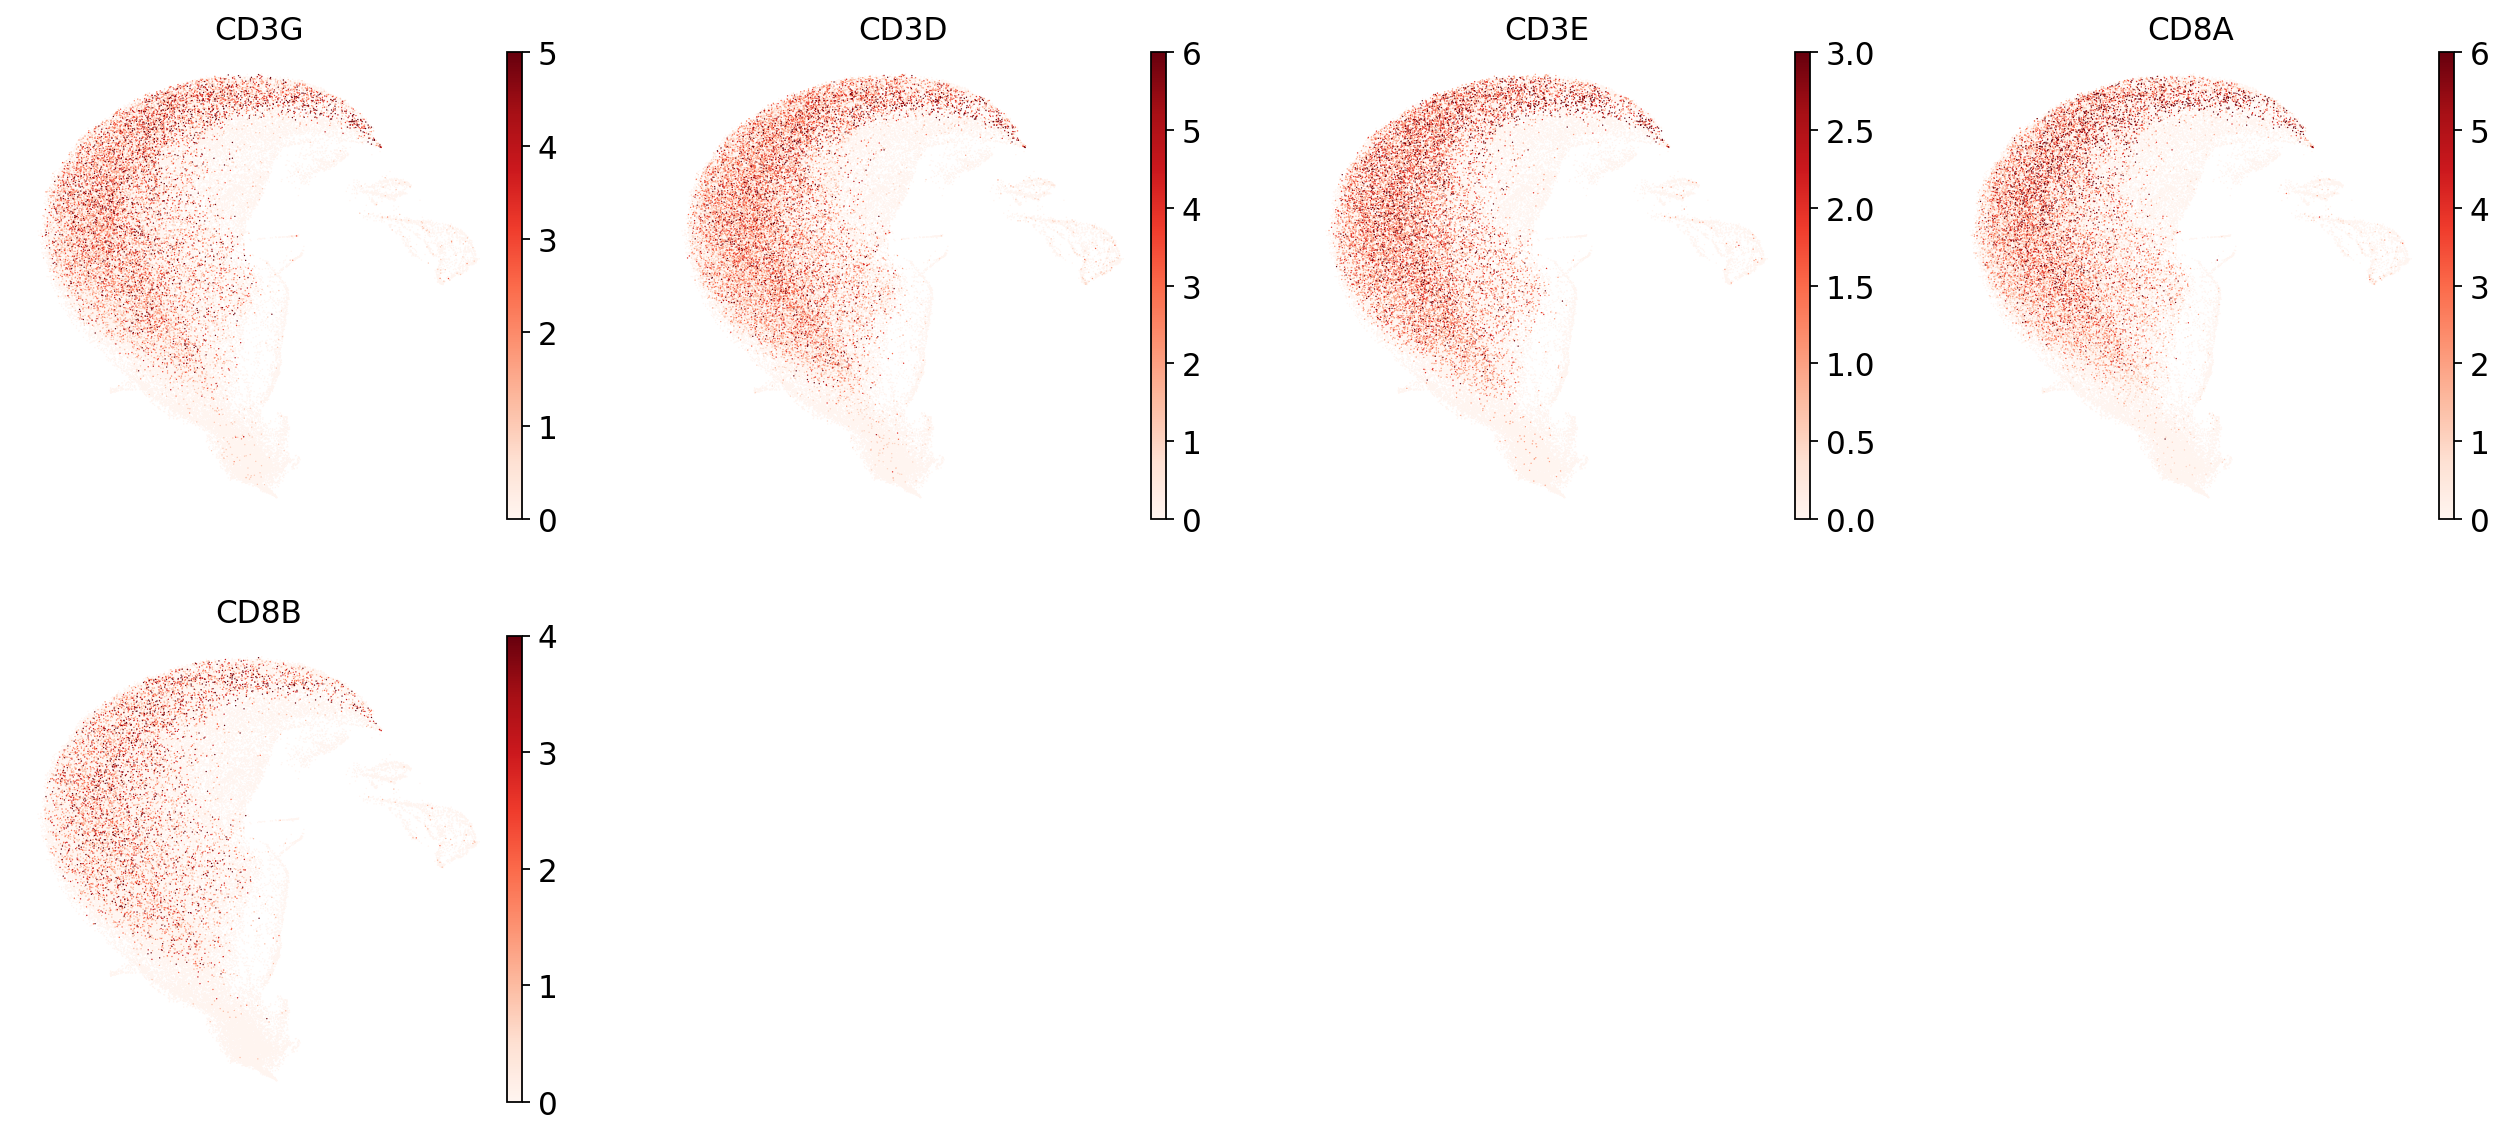

In [13]:
## CHECK CD3 AND CD8
# CD3 AND CD8 markerS  
markers = ['CD3G','CD3D','CD3E','CD8A','CD8B']
#use as max the 99 percentile
sc.pl.umap(adata, color = markers, vmin=0,vmax="p99", frameon=False, cmap="Reds")

In [14]:
merge_df = pd.DataFrame(adata.X, columns=adata.var.index,index=(adata.obs.index))
merge_df

,5S_rRNA,7SK,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,...,snoZ178,snoZ185,snoZ247,snoZ278,snoZ40,snoZ5,snoZ6,snosnR60_Z15,snosnR66,yR211F11.2
W461969,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
W461970,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
W461971,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
W461972,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
W461973,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WMC810396,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WMC810397,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WMC810398,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WMC810399,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
## FILTER CD3 AND CD8
#at least one of CD3 > 0
CD3 = merge_df[['CD3D','CD3E','CD3G']]
CD8 = merge_df[['CD8A','CD8B']]

In [20]:
CD3_1 = CD3.loc[(CD3 > 0).any(axis=1)]
CD8_1 = CD8.loc[(CD8 > 0).any(axis=1)]

In [21]:
index_CD3 = CD3_1.index
index_CD8 = CD8_1.index

In [22]:
index_CD3 = index_CD3.tolist()
index_CD8 = index_CD8.tolist()

In [27]:
common_barcodes = list(set(index_CD3) & set(index_CD8))

In [28]:
# filter just the barcode of CD3 and CD8 cells
adata = adata[adata.obs.index.isin(common_barcodes)]

In [29]:
adata

View of AnnData object with n_obs × n_vars = 12136 × 55765
    obs: 'samples', 'patient', 'tumor_location', 'disease_stage', 'prior_treatment', 'on_treatment', 'groups', 'LN-SC groups'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [30]:
## FILTER CD3 -> 29414 cells

In [31]:
#at least one of CD3 > 0
#CD3 = merge_df[['CD3D','CD3E','CD3G']]
#CD3_1 = CD3.loc[(CD3 > 0).any(axis=1)]

In [32]:
#index = CD3_1.index

In [33]:
#index = index.tolist()

In [34]:
# filter just the barcode of CD3 cells
#adata = adata[adata.obs.index.isin(index)]

In [35]:
## FILTER CD8 -> 17475 cells
#at least one of CD8 > 0
#CD8 = merge_df[['CD8A','CD8B']]
#CD8_1 = CD8.loc[(CD8 > 0).any(axis=1)]

In [15]:
#index = CD8_1.index

In [36]:
#index = index.tolist()

In [37]:
# filter just the barcode of CD8 cells
#adata = adata[adata.obs.index.isin(index)]

In [71]:
#adata.write('/mnt/projects/labs/NTBLAB/collab/adata_CD3_CD8.h5')

In [356]:
adata = sc.read('/mnt/projects/labs/collab/adata_CD3_CD8.h5')

In [357]:
adata

AnnData object with n_obs × n_vars = 12136 × 55765
    obs: 'samples', 'patient', 'tumor_location', 'disease_stage', 'prior_treatment', 'on_treatment', 'groups', 'LN-SC groups'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [358]:
adata.var

""
5S_rRNA
7SK
A1BG
A1BG-AS1
A1CF
...
snoZ5
snoZ6
snosnR60_Z15
snosnR66


In [332]:
# CCR9 marker  
marker = ['CD3D']
sc.pl.umap(adata, color = marker, frameon=False, cmap="Reds")

In [333]:
# CCR9 marker  
marker = ['CCR9']
sc.pl.umap(adata, color = marker, frameon=False, cmap="Reds")

In [334]:
# CCR9 marker  
marker = ['CCR9']
#use as max the 99 percentile
sc.pl.umap(adata, color = marker, vmin=0,vmax="p99", frameon=False, cmap="Reds")

In [335]:
marker=['CCR9']

In [336]:
sc.pl.dotplot(adata, marker, "groups", standard_scale= 'var',dot_min = 0, log = True)

In [337]:
new_order = ['PBMC non-treated', 'LN treated', 'LN non-treated', 'Tumour treated', 'Tumour non-treated']  # Specify your desired order
adata.obs['groups'] = pd.Categorical(adata.obs['groups'], categories=new_order, ordered=True)


In [338]:
new_order = ['PBMC', 'non-treated', 'prior treatment', 'on-treatment']  # Specify your desired order
adata.obs['LN-SC groups'] = pd.Categorical(adata.obs['LN-SC groups'], categories=new_order, ordered=True)


In [50]:
import matplotlib
matplotlib.use('Agg')

In [343]:
fig,ax = plt.subplots(figsize=(4,4))
ax = sc.pl.dotplot(adata, marker, "groups", dot_max = 0.001, dot_min = 0, log = True,standard_scale='var',ax=ax)
plt.savefig('dotplot_groups.png', dpi = 300,bbox_inches='tight')
plt.savefig('dotplot_groups.pdf', dpi = 300,bbox_inches='tight')
plt.show()

In [341]:
fig,ax = plt.subplots(figsize=(4,4))
ax = sc.pl.dotplot(adata, marker, "LN-SC groups", dot_max = 0.01, dot_min = 0, log = True,standard_scale='var',ax=ax)
plt.savefig('dotplot_LN-SC_groups.png', dpi = 300,bbox_inches='tight')
plt.savefig('dotplot_LN-SC_groups.pdf', dpi = 300,bbox_inches='tight')
plt.show()

In [342]:
fig,ax = plt.subplots(figsize=(4,13))
ax = sc.pl.dotplot(adata, marker, "patient", dot_max = 0.001, dot_min = 0, log = True,standard_scale='var',ax=ax)
plt.savefig('dotplot_patient.png', dpi = 300,bbox_inches='tight')
plt.savefig('dotplot_patient.pdf', dpi = 300,bbox_inches='tight')
plt.show()

In [54]:
adata.obs

,samples,patient,tumor_location,disease_stage,prior_treatment,on_treatment,groups,LN-SC groups
W461971,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461980,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461984,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461986,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461987,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
...,...,...,...,...,...,...,...,...
WMC810381,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC
WMC810383,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC
WMC810390,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC
WMC810392,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC


In [55]:
expression = pd.DataFrame(adata.X, columns=adata.var.index,index=(adata.obs.index))

In [56]:
patient = adata.obs['patient']
expression = pd.concat([expression,patient], axis = 1)
expression

,5S_rRNA,7SK,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,...,snoZ185,snoZ247,snoZ278,snoZ40,snoZ5,snoZ6,snosnR60_Z15,snosnR66,yR211F11.2,patient
W461971,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,p2
W461980,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,p2
W461984,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,p2
W461986,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,p2
W461987,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,p2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WMC810381,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,p27-PB
WMC810383,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,p27-PB
WMC810390,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,p27-PB
WMC810392,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,p27-PB


In [57]:
groups = adata.obs['groups']
expression = pd.concat([expression,groups], axis = 1)
expression

,5S_rRNA,7SK,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,...,snoZ247,snoZ278,snoZ40,snoZ5,snoZ6,snosnR60_Z15,snosnR66,yR211F11.2,patient,groups
W461971,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,p2,LN treated
W461980,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,p2,LN treated
W461984,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,p2,LN treated
W461986,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,p2,LN treated
W461987,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,p2,LN treated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WMC810381,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,p27-PB,PBMC non-treated
WMC810383,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,p27-PB,PBMC non-treated
WMC810390,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,p27-PB,PBMC non-treated
WMC810392,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,p27-PB,PBMC non-treated


In [58]:
expression.columns[expression.isnull().any()]

Index([], dtype='object')

In [59]:
expression.isnull().sum()

5S_rRNA         0
7SK             0
A1BG            0
A1BG-AS1        0
A1CF            0
               ..
snosnR60_Z15    0
snosnR66        0
yR211F11.2      0
patient         0
groups          0
Length: 55767, dtype: int64

In [60]:
# Calculate mean expression for each patient within their group
mean_expression = expression.groupby(['groups', 'patient'])['CCR9'].mean()


In [61]:
mean_expression = mean_expression.fillna(0)

In [62]:
mean_expression = pd.DataFrame(mean_expression)

In [212]:
pd.set_option('display.max_rows', 10)


In [131]:
mean_expression

CCR9
groups             patient          
LN non-treated     p1       0.000000
                   p2       0.000000
                   p3       0.000000
                   p4       0.000000
                   p5       0.000000
                   p6       0.000000
                   p8       0.000000
                   p9       0.000000
                   p11      0.000000
                   p12-1    0.000000
                   p12-2    0.000000
                   p13      0.000000
                   p13-PB   0.000000
                   p15      0.000000
                   p16      0.000000
                   p17-1    0.000000
                   p17-2    0.000000
                   p17-PB   0.000000
                   p18      0.000000
                   p19      0.000000
                   p20      0.000000
                   p21      0.000000
                   p22      0.000000
                   p23      0.000000
                   p24-2    0.000000
                   p26      0.000000
                   p27      0.000000
                   p27-PB   0.000000
                   p28      0.000000
LN treated         p1       0.000000
                   p2       0.021978
                   p3       0.000000
                   p4       0.000000
                   p5       0.000000
                   p6       0.000000
                   p8       0.000000
                   p9       0.009580
                   p11      0.000000
                   p12-1    0.000000
                   p12-2    0.000000
                   p13      0.000000
                   p13-PB   0.000000
                   p15      0.000000
                   p16      0.000000
                   p17-1    0.000000
                   p17-2    0.000000
                   p17-PB   0.000000
                   p18      0.000000
                   p19      0.000000
                   p20      0.000000
                   p21      0.000000
                   p22      0.000000
                   p23      0.000000
                   p24-2    0.000000
                   p26      0.000000
                   p27      0.000000
                   p27-PB   0.000000
                   p28      0.000000
PBMC non-treated   p1       0.000000
                   p2       0.000000
                   p3       0.000000
                   p4       0.000000
                   p5       0.000000
                   p6       0.000000
                   p8       0.000000
                   p9       0.000000
                   p11      0.000000
                   p12-1    0.000000
                   p12-2    0.000000
                   p13      0.000000
                   p13-PB   0.000000
                   p15      0.000000
                   p16      0.000000
                   p17-1    0.000000
                   p17-2    0.000000
                   p17-PB   0.000000
                   p18      0.000000
                   p19      0.000000
                   p20      0.000000
                   p21      0.000000
                   p22      0.000000
                   p23      0.000000
                   p24-2    0.000000
                   p26      0.000000
                   p27      0.000000
                   p27-PB   0.000000
                   p28      0.000000
Tumour non-treated p1       0.000000
                   p2       0.000000
                   p3       0.000607
                   p4       0.000000
                   p5       0.000000
                   p6       0.000000
                   p8       0.000000
                   p9       0.000000
                   p11      0.000000
                   p12-1    0.000000
                   p12-2    0.000000
                   p13      0.000000
                   p13-PB   0.000000
                   p15      0.000000
                   p16      0.000000
                   p17-1    0.000000
                   p17-2    0.000000
                   p17-PB   0.000000
                   p18      0.004630
                   p19      0.001464

In [65]:
mean_expression.to_excel('mean_expression_CCR9.xlsx')

In [66]:
# plot the mean expression
plt.figure(figsize=(20, 6))
sns.barplot(data=mean_expression, x='patient', y='CCR9', hue='groups')

plt.xlabel('Patient')
plt.ylabel('Mean CCR9')
plt.title('Mean CCR9 by Patient and Group')
plt.legend(title='Groups')
plt.show()


In [70]:
#to convert jupyter notebook in html format
import os
os.system('jupyter nbconvert --to html CCR9.ipynb')

[NbConvertApp] Converting notebook CCR9.ipynb to html
[NbConvertApp] Writing 2098064 bytes to CCR9.html


0

In [353]:
p4= adata[adata.obs['patient'] == 'p4']
p4

View of AnnData object with n_obs × n_vars = 1373 × 55765
    obs: 'samples', 'patient', 'tumor_location', 'disease_stage', 'prior_treatment', 'on_treatment', 'groups', 'LN-SC groups'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [354]:
p4 = expression.loc[expression['patient']=='p4']
p4 = p4[['CCR9']]
p4

,CCR9
WMC286245,0
WMC286246,0
WMC286250,0
WMC286251,0
WMC286252,0
...,...
WMC291187,0
WMC291188,0
WMC291220,0
WMC291230,0


In [355]:
for i in p4['CCR9']:
    if i > 0:
        print(i)

2
1
5
3
1


In [216]:
ln_treated = expression.loc[expression['groups'] == 'LN treated']

In [220]:
ln_treated[['CCR9']]

,CCR9
W461971,0
W461980,0
W461984,0
W461986,0
W461987,0
...,...
WMC331163,0
WMC331166,0
WMC331413,0
WMC331469,0


In [223]:
ln_treated[['GZMA','GZMB','GZMH','NKG7','PRF1']].sum()

GZMA    3181
GZMB    3017
GZMH    1491
NKG7    6359
PRF1    3006
dtype: int64

In [227]:
ln_treated= adata[adata.obs['groups']=='LN treated']

In [228]:
# CCR9 marker  
marker = ['GZMA','GZMB','GZMH','NKG7','PRF1']
sc.pl.umap(ln_treated, color = marker, frameon=False, cmap="Reds")

In [232]:
CCR9 = expression[['CCR9']]

In [236]:
for index, i in enumerate(CCR9['CCR9']):
    if i > 0:
        print(index,i)

152 1
172 3
1285 1
4469 2
4753 3
4942 1
5347 1
5654 4
5840 4
6146 1
6474 2
6522 2
6981 1
8171 2
8427 1
8460 5
8485 3
9169 1


In [257]:
CCR9.index[9169]

'WMC289799'

In [262]:
CCR9_positive = expression.T[['W542432','W542607','W688809','W844230','WMC0031765','WMC0032342','WMC0035330','WMC0035895',
                'WMC0036352','WMC0037900','WMC0038787','WMC0038874','WMC0109799','WMC286317','WMC286848','WMC286932',
                'WMC286988','WMC289799']]
    
    

In [263]:
adata.obs

AnnData object with n_obs × n_vars = 12136 × 55765
    obs: 'samples', 'patient', 'tumor_location', 'disease_stage', 'prior_treatment', 'on_treatment', 'groups', 'LN-SC groups'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [265]:
p22 = adata[adata.obs['patient'] == 'p22']
p22

View of AnnData object with n_obs × n_vars = 279 × 55765
    obs: 'samples', 'patient', 'tumor_location', 'disease_stage', 'prior_treatment', 'on_treatment', 'groups', 'LN-SC groups'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'